<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
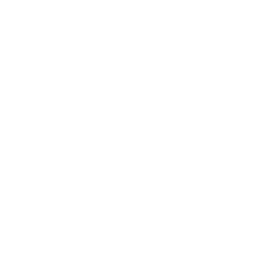
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Molekulare Subtyp-Klassifikation aus Genexpression</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotechnologie / Genomische Onkologie &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Klassifizieren Sie Tumorbiopsie-Proben anhand von Genexpressions-Biomarker-Panels in vier molekulare Subtypen (Luminal-A, Luminal-B, HER2-angereichert, Basal-ähnlich). Wenden Sie die kanonische Diskriminanzanalyse an, um den hochdimensionalen Expressionsraum auf interpretierbare Variationsachsen zu reduzieren. Verwenden Sie MANOVA, um zu prüfen, ob sich die mittleren Expressionsprofile signifikant zwischen den Subtypen unterscheiden. Führen Sie eine Kreuzvalidierung durch, um die Klassifikationszuverlässigkeit für die klinische Entscheidungsunterstützung bei der Auswahl des Behandlungspfads abzuschätzen.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.GENE_EXPR | Tumor-Genexpression mit Subtyp-Labels | 100 |
| WORK.NEW_BIOPSIES | Nicht klassifizierte Biopsie-Proben | 100 |


---

In [1]:
/* --------------------------------------------------------
   Synthetischen Genexpressions-Datensatz mit vier
   molekularen Subtypen erzeugen
   -------------------------------------------------------- */
DATEN work.gene_expr;
    AUFRUFEN streaminit(42);
    LÄNGE mol_subtype $12;
    FELD subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    AUSFÜHRUNG sample_id = 1 BIS 100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Simulierte Genexpressions-Marker (log2-Skala) */
        AUSWÄHLEN (mol_subtype);
            FALLS ('LUMINAL_A') AUSFÜHRUNG;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            ENDE;
            FALLS ('LUMINAL_B') AUSFÜHRUNG;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            ENDE;
            FALLS ('HER2_ENRICH') AUSFÜHRUNG;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            ENDE;
            FALLS ('BASAL_LIKE') AUSFÜHRUNG;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            ENDE;
            ANDERNFALLS;
        ENDE;
        AUSGABE;
    ENDE;
    ENTFERNEN sub_idx;
AUSFÜHREN;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Nicht klassifizierte Biopsie-Proben erzeugen
   -------------------------------------------------------- */
DATEN work.new_biopsies;
    AUFRUFEN streaminit(55);
    AUSFÜHRUNG sample_id = 5001 BIS 5100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        AUSGABE;
    ENDE;
AUSFÜHREN;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                          Verteilung der molekularen Subtypen                                           

                                                   The FREQ Procedure

Molekularer Subtyp    Frequency    Percent
-------------------------------------------
BASAL_LIKE                   24     24.00
HER2_ENRICH                  22     22.00
LUMINAL_A                    25     25.00
LUMINAL_B                    29     29.00
                                    Genexpressions-Übersicht nach molekularem Subtyp                                    

                                                  The MEANS Procedure

                                  Analysis Variable : esr1_expr ESR1-Expression (log2)

        Molekularer Subtyp          N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        BASAL_LIKE                     24      4.5479167      1.2257100
        HER2_ENRICH                    22      7.131818


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


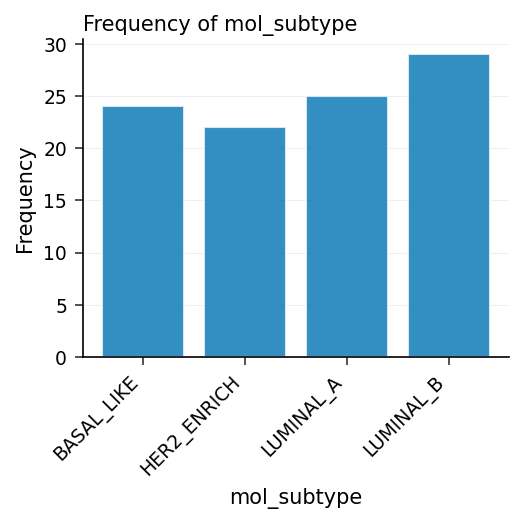

In [3]:
/* --------------------------------------------------------
   Basis-Subtypverteilung und Expressionsprofile
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.gene_expr;
    TABLES mol_subtype / nocum;
    BEZEICHNUNG mol_subtype='Molekularer Subtyp';
    TITEL 'Verteilung der molekularen Subtypen';
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=work.gene_expr n mean std;
    KLASSE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    BEZEICHNUNG mol_subtype='Molekularer Subtyp'
          esr1_expr='ESR1-Expression (log2)'
          pgr_expr='PGR-Expression (log2)'
          erbb2_expr='ERBB2-Expression (log2)'
          ki67_expr='Ki-67-Expression (log2)'
          egfr_expr='EGFR-Expression (log2)'
          cytokeratin5='Cytokeratin-5 (log2)'
          tp53_mut_load='TP53-Mutationslast'
          prolif_score='Proliferations-Score';
    TITEL 'Genexpressions-Übersicht nach molekularem Subtyp';
AUSFÜHREN;

---

In [4]:
/* --------------------------------------------------------
   Kanonische Diskriminanzanalyse mit MANOVA
   CANONICAL extrahiert Diskriminanzachsen zur Visualisierung.
   MANOVA prüft die gesamte Mittelwerttrennung über die Subtypen.
   -------------------------------------------------------- */
PROZEDUR DISCRIM DATEN=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    KLASSE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    BEZEICHNUNG mol_subtype='Molekularer Subtyp'
          esr1_expr='ESR1-Expression (log2)'
          pgr_expr='PGR-Expression (log2)'
          erbb2_expr='ERBB2-Expression (log2)'
          ki67_expr='Ki-67-Expression (log2)'
          egfr_expr='EGFR-Expression (log2)'
          cytokeratin5='Cytokeratin-5 (log2)'
          tp53_mut_load='TP53-Mutationslast'
          prolif_score='Proliferations-Score';
    TITEL 'Kanonische Diskriminanzanalyse: Molekulare Tumor-Subtypen';
    title2 'MANOVA-Test der Unterschiede mittlerer Expressionsprofile';
AUSFÜHREN;

                                    Genexpressions-Übersicht nach molekularem Subtyp                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                    Genexpressions-Übersicht nach molekularem Subtyp                                    




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


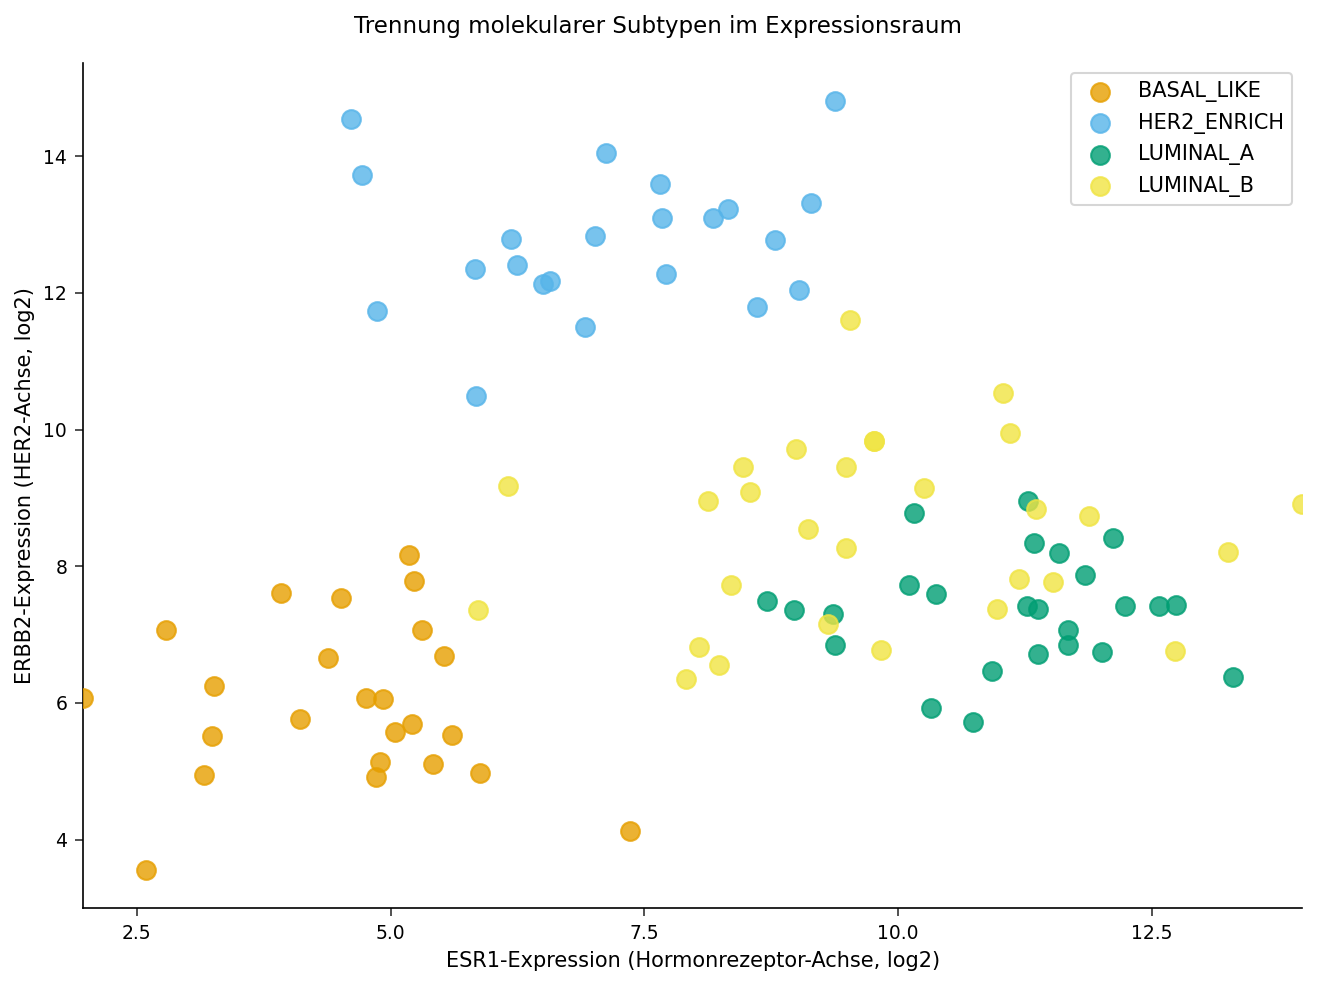

In [5]:
/* --------------------------------------------------------
   Trennung der Subtypen im Expressionsraum
   ESR1 (Hormonrezeptor-Achse) vs. ERBB2 (HER2-Achse),
   aus dem Diskriminanz-OUT=-Datensatz.
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS BEZEICHNUNG='ESR1-Expression (Hormonrezeptor-Achse, log2)';
    YAXIS BEZEICHNUNG='ERBB2-Expression (HER2-Achse, log2)';
    TITEL 'Trennung molekularer Subtypen im Expressionsraum';
AUSFÜHREN;

In [6]:
/* --------------------------------------------------------
   Nicht typisierte Biopsie-Proben klassifizieren
   -------------------------------------------------------- */
PROZEDUR DISCRIM DATEN=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    KLASSE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    BEZEICHNUNG mol_subtype='Molekularer Subtyp'
          esr1_expr='ESR1-Expression (log2)'
          pgr_expr='PGR-Expression (log2)'
          erbb2_expr='ERBB2-Expression (log2)'
          ki67_expr='Ki-67-Expression (log2)'
          egfr_expr='EGFR-Expression (log2)'
          cytokeratin5='Cytokeratin-5 (log2)'
          tp53_mut_load='TP53-Mutationslast'
          prolif_score='Proliferations-Score';
    TITEL 'Molekulare Subtyp-Klassifikation neuer Biopsien';
AUSFÜHREN;

                                    Genexpressions-Übersicht nach molekularem Subtyp                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                              Vorhergesagte Verteilung molekularer Subtypen: Neue Biopsien                              

                                                   The FREQ Procedure

Vorhergesagter molekularer Subtyp    Frequency    Percent
----------------------------------------------------------
BASAL_LIKE                                   7      7.00
HER2_ENRICH                                 47     47.00
LUMINAL_A                                   10     10.00
LUMINAL_B                                   36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


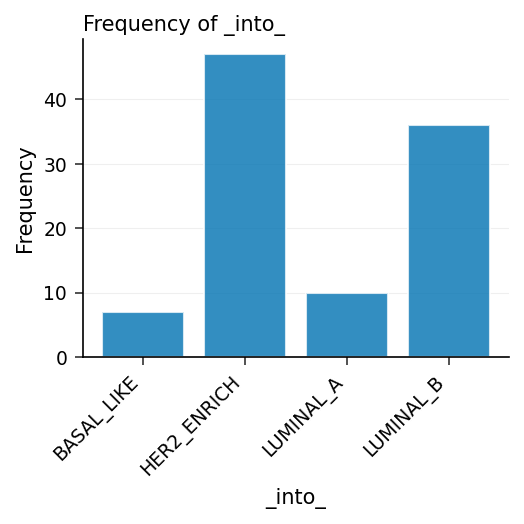

In [7]:
/* --------------------------------------------------------
   Klassifikationsverteilung für neue Biopsien
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.classified_biopsies;
    TABLES _into_ / nocum;
    BEZEICHNUNG _into_='Vorhergesagter molekularer Subtyp';
    TITEL 'Vorhergesagte Verteilung molekularer Subtypen: Neue Biopsien';
AUSFÜHREN;

---

### Interpretation

Der MANOVA-Test bestätigt einen hochsignifikanten Unterschied in den mittleren Genexpressionsprofilen zwischen den vier molekularen Subtypen: Wilks' Lambda = 0.0037 mit p < 0.0001, sodass die Subtypen klar abgegrenzte Regionen des aus acht Markern bestehenden Expressionsraums einnehmen. Diese Trennung ist im Streudiagramm des Expressionsraums sichtbar, in dem Luminal-Tumoren hoch auf der ESR1-Achse (Hormonrezeptor) liegen, während HER2-angereicherte Tumoren an die Spitze der ERBB2-Achse drängen und Basal-ähnliche Tumoren nach unten links auf beiden Achsen fallen. Die Resubstitutions-Klassifikation der 100 gelabelten Tumoren ist perfekt (0 % scheinbarer Fehler), und die Leave-One-Out-Kreuzvalidierung beziffert die Fehlerrate auf lediglich 4 % — eine ehrliche kreuzvalidierte Genauigkeit von 96 %, wobei jeder Subtyp in der kreuzvalidierten Konfusionsmatrix korrekt wiederhergestellt wird. Die Anwendung des trainierten Klassifikators auf die 100 nicht gelabelten Biopsien ordnet 47 dem HER2-angereicherten, 36 dem Luminal-B-, 10 dem Luminal-A- und 7 dem Basal-ähnlichen Subtyp zu; die Tendenz zu HER2-angereichert spiegelt die erhöhten ERBB2- und Proliferationswerte des Biopsie-Panels wider. Diese Subtyp-Zuordnungen steuern die Auswahl des Behandlungspfads: endokrine Therapie für Luminal-Tumoren, gezielte Anti-HER2-Wirkstoffe für die HER2-angereicherte Gruppe und Chemotherapie-Schemata für Basal-ähnliche Tumoren.


---

In [8]:
/* --------------------------------------------------------
   Klassifizierte Biopsien für die Behandlungsplanung exportieren
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>